In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")

In [2]:
using Revise

In [3]:
using PyPlot, PyCall, Peaks, JJDFTX, LinearAlgebra

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [11]:
lattice_vectors = loadlattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [8.7558684774, -2.1665141392400002, 0.0]
 [-6.2541842099, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [16]:
unit_cell_area(lattice_vectors)

70.45910242916717

In [22]:
kpts = bandstructkpoints2q();
kpts_unnormalized = unnormalize_kvector.(Ref(lattice_vectors), kpts);

In [39]:
e_backgrounds = 1 .+ 12.6*bohrtoangstrom*[sqrt(sum(k.^2)) for k in kpts_unnormalized];

In [32]:
Hwannierup, cellmapup = hwannier("wannier-0.289Up.txt", "wannier-0.289Up.map.txt"), np.loadtxt("wannier-0.289Up.map.txt");
Hwannierdn, cellmapdn = hwannier("wannier-0.289Dn.txt", "wannier-0.289Dn.map.txt"), np.loadtxt("wannier-0.289Dn.map.txt");

In [33]:
bands = np.reshape(np.fromfile("Na-bands-0.289.eigenvals"), (112, -1))*27.2
bandsup = bands[1:56, :]
bandsdn = bands[57:end, :];

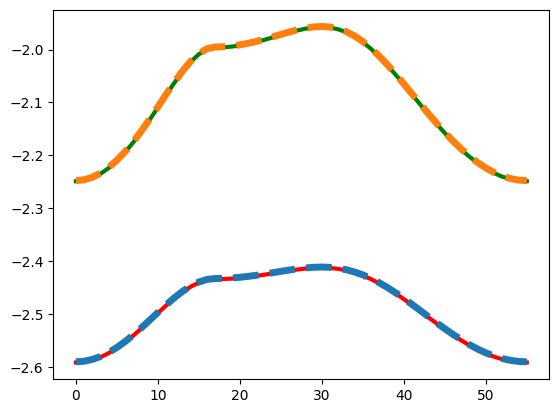

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f19f6f9bca0>

In [34]:
plotwannierbands(Hwannierup, cellmapup, 1, linewidth=3, color="red")
plotwannierbands(Hwannierdn, cellmapdn, 1, linewidth=3, color="green")
plot(bandsup[:, 109], linestyle="dashed", linewidth=5)
plot(bandsdn[:, 109], linestyle="dashed", linewidth=5)

In [77]:
impols = []
for q in kpts
    up = im_polarization(Hwannierup, cellmapup, lattice_vectors, q, -2.5;spin=1, mesh=180, histogram_width=100, normalized=true, verbose=true) 
    push!(impols, up)
end

[0.0, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.512820512769, -0.025641025385, 0.0]
[0.525641025538, -0.051282050769, 0.0]
[0.538461538308, -0.076923076154, 0.0]
[0.551282051077, -0.102564101538, 0.0]
[0.564102563846, -0.128205126923, 0.0]
[0.576923076615, -0.153846152308, 0.0]
[0.589743589385, -0.179487177692, 0.0]
[0.602564102154, -0.205128203077, 0.0]
[0.615384614923, -0.230769228462, 0.0]
[0.628205127692, -0.256410253846, 0.0]
[0.641025640462, -0.282051279231, 0.0]
[0.653846153231, -0.307692304615, 0.0]
[0.666666666, -0.33333333, 0.0]
[0.63999999936, -0.3199999968, 0.0]


In [38]:
0.285*40*0.529

6.0306

In [86]:
realpols = zeros(56, 100)

for (i, line) in enumerate(readlines("bandstruct.kpoints")[3:end])
    e_background = e_backgrounds[i]
    q = parse.(Float64, split(line)[2:4])
    b1 = unnormalize_kvector(lattice_vectors, q)
    screening=exp(-6.036*sqrt(sum(b1.^2)))
    for (j, omega) in enumerate(range(0.1, 0.45, length=100))
        eps = return_2d_epsilon(q, lattice_vectors, omega, impols[i], 100, 100)
        realpols[i, j] = real(eps)+2*(e_background-1)*screening/(1+(e_background-1)*(1-screening))
    end
end

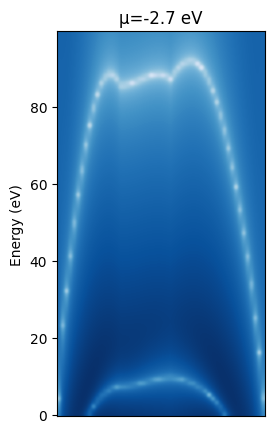

PyObject Text(0.5, 1.0, 'μ=-2.7 eV')

In [93]:
#energyrange = round.(range(0.1, 0.45 , length=3), digits=3)
energyrange2 = round.(range(0.1, 0.45, length=1), digits=3)
figure(figsize=(5, 5))
#subplot(1, 3, 1)
imshow(transpose(smooth(log.(abs.(realpols[2:end-1, :])) .+1, win_len=1)), interpolation="gaussian", cmap="Blues", origin="lower")
ylabel("Energy (eV)")
#yticks(range(0, 99, length=10), energyrange )
xticks([])
title("μ=-2.7 eV")
#hlines(round(argmin(abs.(energyrange2 .- 1.07))), 0, 52, color="black", linestyle="dotted", linewidth=4)



In [103]:
y = range(0.1, 0.45, length=100)

0.1:0.0035353535353535356:0.45

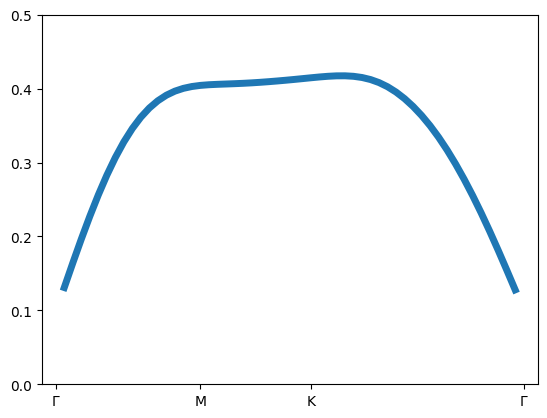

(0.0, 0.5)

In [160]:
plasmon = smooth([y[argmin(x)] for x in eachrow(log.(abs.(smooth(realpols[2:end-1, :], win_len=4) )))], win_len=20)
plot(1:54, plasmon, linewidth=5)
label_plots("../../bandstruct.kpoints.in", "../../bandstruct.kpoints")
#xlim(0, 20)
ylim(0, 0.5)

In [170]:
λs = 2π ./ [sqrt(sum(k.^2)) for k in kpts_unnormalized][2:end-1] * 1/10; # (Convert from angstroms to nanometers)

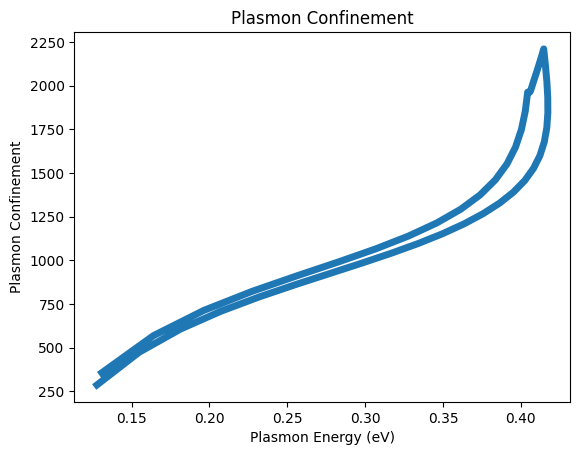

PyObject Text(0.5, 1.0, 'Plasmon Confinement')

In [173]:
plot(plasmon , 1240 ./ plasmon ./λs, linewidth=5)
xlabel("Plasmon Energy (eV)")
ylabel("Plasmon Confinement")
title("Plasmon Confinement")

In [172]:
(0.42/0.37)^2

1.2885317750182614